# Train Cell2Sentence with HCE Loss on Lung Dataset

This notebook demonstrates how to:
1. Load the lung.h5ad dataset
2. Build a cell type hierarchy for HCE loss
3. Train a Cell2Sentence model with Hierarchical Cross-Entropy (HCE) loss

**What is HCE Loss?**
Hierarchical Cross-Entropy loss leverages the hierarchical structure of cell types, accounting for parent-child relationships. This leads to more biologically informed models that respect the cell type ontology.

## 1. Import Required Libraries

In [1]:
import os
import sys
import scanpy as sc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel, TrainingArguments
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Add cell2sentence to path
sys.path.insert(0, '/home/hugolab/Documents/Cell2Sentence-HugoLab/Cell2Sentence-HugoLab/src')

from cell2sentence.hce_trainer import build_reachability_matrix_from_ontology

print("Libraries imported successfully!")

/home/hugolab/Documents/Cell2Sentence-HugoLab/Cell2Sentence-HugoLab/c2s-justin/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries imported successfully!


## 2. Configuration

Set up the paths and hyperparameters for training.

In [2]:
# Configuration
LUNG_H5AD_PATH = '/home/hugolab/Documents/Cell2Sentence-HugoLab/Cell2Sentence-HugoLab/lung.h5ad'
SAVE_DIR = '/home/hugolab/Documents/Cell2Sentence-HugoLab/Cell2Sentence-HugoLab/outputs'
# Use the working C2S model from lung_even_consistency
MODEL_NAME = 'vandijklab/C2S-Pythia-410m-cell-type-conditioned-cell-generation'
USE_HCE_LOSS = True
TOP_K_GENES = 100

# Training parameters
BATCH_SIZE = 8
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
TEST_FRAC = 0.15
N_EPOCHS = 3
LEARNING_RATE = 5e-5

# Device configuration
def get_device():
    if torch.cuda.is_available():
        device = torch.device("cuda")
        print(f"Using CUDA GPU: {torch.cuda.get_device_name(0)}")
    elif torch.backends.mps.is_available() and torch.backends.mps.is_built():
        device = torch.device("mps")
        print("Using Apple Metal Performance Shaders (MPS)")
    else:
        device = torch.device("cpu")
        print("Using CPU (no GPU detected)")
    return device

device = get_device()

# Create output directory
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"\nConfiguration:")
print(f"  Dataset: {LUNG_H5AD_PATH}")
print(f"  Model: {MODEL_NAME}")
print(f"  Device: {device}")
print(f"  Use HCE Loss: {USE_HCE_LOSS}")
print(f"  Top K Genes: {TOP_K_GENES}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Train/Val/Test: {TRAIN_FRAC}/{VAL_FRAC}/{TEST_FRAC}")

Using CUDA GPU: NVIDIA GeForce RTX 5060 Ti

Configuration:
  Dataset: /home/hugolab/Documents/Cell2Sentence-HugoLab/Cell2Sentence-HugoLab/lung.h5ad
  Model: vandijklab/C2S-Pythia-410m-cell-type-conditioned-cell-generation
  Device: cuda
  Use HCE Loss: True
  Top K Genes: 100
  Batch Size: 8
  Train/Val/Test: 0.7/0.15/0.15


## 3. Load and Explore the Dataset

Load the lung.h5ad dataset and inspect its structure.

In [29]:
# Load the dataset in backed mode (memory efficient)
print(f"Loading data from {LUNG_H5AD_PATH} (backed mode)...")
adata = sc.read_h5ad(LUNG_H5AD_PATH, backed='r')

print(f"\nOriginal dataset shape: {adata.shape}")

# Balanced sampling by capping cells per type
# This creates a more balanced dataset for training
print("\n" + "=" * 80)
print("BALANCED SAMPLING: Capping cells per type")
print("=" * 80)

# Configuration for balanced sampling
MIN_CELLS_PER_TYPE = 10   # Minimum cells required to keep a cell type
MAX_CELLS_PER_TYPE = 1000  # Maximum cells per cell type (cap)
ANN_COL = 'ann_finest_level'  # Column to use for balancing

# Check if annotation column exists
if ANN_COL not in adata.obs.columns:
    print(f"⚠️  Warning: '{ANN_COL}' not found. Using the entire dataset.")
    # Use entire dataset without cap
    adata = adata.to_memory()
else:
    # Build balanced sample by capping each cell type
    print(f"Sampling configuration:")
    print(f"  Min cells per type: {MIN_CELLS_PER_TYPE}")
    print(f"  Max cells per type: {MAX_CELLS_PER_TYPE}")
    print(f"  Annotation column: {ANN_COL}")
    
    labels = adata.obs[ANN_COL].astype(str)
    counts = labels.value_counts()
    
    # Keep only sufficiently represented classes
    keep_labels = counts[counts >= MIN_CELLS_PER_TYPE].index.tolist()
    # Filter out 'Unknown' if present
    keep_labels = [lbl for lbl in keep_labels if lbl not in ['unknown', 'Unknown', 'nan', 'NA']]
    
    print(f"\n✅ Keeping {len(keep_labels)} cell types with >= {MIN_CELLS_PER_TYPE} cells")
    print(f"   Dropped {len(counts) - len(keep_labels)} cell types (too rare or unknown)")
    
    # Sample up to max_per_type from each kept label
    np.random.seed(42)
    sampled_idx = []
    
    for lbl in keep_labels:
        idxs = np.where(labels.values == lbl)[0]
        n_keep = min(len(idxs), MAX_CELLS_PER_TYPE)
        chosen = np.random.choice(idxs, size=n_keep, replace=False)
        sampled_idx.extend(chosen.tolist())
    
    # Create sampled AnnData (preserve ordering)
    sampled_idx = np.array(sampled_idx, dtype=int)
    sampled_idx = np.sort(sampled_idx)  # Sort to maintain order
    
    adata = adata[sampled_idx].to_memory()
    
    print(f"\n📊 Balanced dataset created:")
    print(f"   Total cells: {adata.n_obs}")
    print(f"   Cell types: {len(adata.obs[ANN_COL].unique())}")
    
    # Show new class distribution
    new_counts = adata.obs[ANN_COL].value_counts().sort_values(ascending=False)
    print(f"\n📊 Top 10 cell types after balancing:")
    for idx, (cell_type, count) in enumerate(new_counts.head(10).items(), 1):
        print(f"   {idx:2d}. {cell_type:40s}: {count:4d} cells")
    
    print(f"\n✅ Dataset is now balanced with max {MAX_CELLS_PER_TYPE} cells per type!")

print(f"\nFinal dataset shape: {adata.shape}")
print(f"Number of cells: {adata.n_obs}")
print(f"Number of genes: {adata.n_vars}")
print(f"\nAvailable metadata columns: {adata.obs.columns.tolist()}")

# Check for cell type columns
cell_type_cols = [col for col in adata.obs.columns if 'cell' in col.lower() or 'type' in col.lower()]
print(f"\nPotential cell type columns: {cell_type_cols}")

Loading data from /home/hugolab/Documents/Cell2Sentence-HugoLab/Cell2Sentence-HugoLab/lung.h5ad (backed mode)...

Original dataset shape: (2282447, 55329)

BALANCED SAMPLING: Capping cells per type
Sampling configuration:
  Min cells per type: 10
  Max cells per type: 1000
  Annotation column: ann_finest_level

✅ Keeping 61 cell types with >= 10 cells
   Dropped 1 cell types (too rare or unknown)

📊 Balanced dataset created:
   Total cells: 57611
   Cell types: 61

📊 Top 10 cell types after balancing:
    1. AT0                                     : 1000 cells
    2. AT1                                     : 1000 cells
    3. AT2                                     : 1000 cells
    4. AT2 proliferating                       : 1000 cells
    5. Adventitial fibroblasts                 : 1000 cells
    6. Alveolar Mph CCL3+                      : 1000 cells
    7. Alveolar Mph MT-positive                : 1000 cells
    8. Alveolar Mph proliferating              : 1000 cells
    9. Alveol

## 4. Build Cell Type Hierarchy

Create a hierarchical structure of cell types for HCE loss. This groups specific cell types into broader categories (e.g., T cells, B cells → Immune Cells).

In [30]:
# Explore the dataset to find hierarchical cell type columns
print("📋 All available columns in dataset:")
print(adata.obs.columns.tolist())

# Look for annotation level columns (HLCA standard)
ann_cols = [col for col in adata.obs.columns if col.startswith('ann_')]
print(f"\n🔍 Annotation columns: {ann_cols}")

# Check if we have the recommended column
if 'ann_finest_level' in adata.obs.columns:
    print(f"\n✅ Found 'ann_finest_level' - using this for classification")
    print(f"   This column provides:")
    print(f"   - Expert consensus annotations (HLCA Core)")
    print(f"   - Quality filtered labels (removes uncertain predictions)")
    print(f"   - Maximum granularity (deepest available level per cell)")
else:
    print(f"\n⚠️  'ann_finest_level' not found")

# Show sample of annotation columns
print("\n📊 Sample of annotation columns:")
if ann_cols:
    print(adata.obs[ann_cols].head(10))
else:
    print("No annotation columns found, showing first few columns:")
    print(adata.obs.iloc[:, :5].head(10))

📋 All available columns in dataset:
['suspension_type', 'donor_id', 'is_primary_data', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'tissue_ontology_term_id', 'sex_ontology_term_id', "3'_or_5'", 'BMI', 'age_or_mean_of_age_range', 'age_range', 'anatomical_region_ccf_score', 'ann_coarse_for_GWAS_and_modeling', 'ann_finest_level', 'ann_level_1', 'ann_level_2', 'ann_level_3', 'ann_level_4', 'ann_level_5', 'cause_of_death', 'core_or_extension', 'dataset', 'fresh_or_frozen', 'log10_total_counts', 'lung_condition', 'mixed_ancestry', 'original_ann_level_1', 'original_ann_level_2', 'original_ann_level_3', 'original_ann_level_4', 'original_ann_level_5', 'original_ann_nonharmonized', 'reannotation_type', 'sample', 'scanvi_label', 'sequencing_platform', 'smoking_status', 'study', 'subject_type', 'tissue_coarse_unharmonized', 'tissue_detailed_unharmonized', 'tissue_dissociation_p

In [31]:
# Build hierarchy from annotation level columns in the dataset
print("=" * 80)
print("BUILDING CELL TYPE HIERARCHY FROM HLCA ANNOTATIONS")
print("=" * 80)

# HLCA (Human Lung Cell Atlas) uses standardized annotation columns:
# - ann_level_1, ann_level_2, ann_level_3, ann_level_4, ann_level_5 (hierarchical levels)
# - ann_finest_level (automatically selects deepest available level per cell)

# Find annotation level columns (ann_level_1, ann_level_2, etc.)
level_columns = sorted([col for col in adata.obs.columns 
                        if col.startswith('ann_level_') and col[-1].isdigit()])

print(f"\n🔍 Found {len(level_columns)} hierarchical annotation levels:")
for col in level_columns:
    n_unique = adata.obs[col].nunique()
    n_not_na = adata.obs[col].notna().sum()
    print(f"  - {col}: {n_unique} unique values ({n_not_na}/{len(adata.obs)} cells annotated)")

if len(level_columns) < 2:
    print("\n⚠️  WARNING: Could not find standard HLCA annotation level columns.")
    print("    Expected columns like: ann_level_1, ann_level_2, ann_level_3, etc.")
    print("    Available columns:", adata.obs.columns.tolist())
    
    # Fallback: use ann_finest_level without hierarchy
    if 'ann_finest_level' in adata.obs.columns:
        cell_type_column = 'ann_finest_level'
        print(f"\n    Using '{cell_type_column}' as a flat classification (no hierarchy)")
        cell_types = adata.obs[cell_type_column].dropna().unique().tolist()
        all_cell_types = cell_types
        ontology_dict = {ct: None for ct in cell_types}  # No parents
    else:
        # Ultimate fallback
        cell_type_column = 'cell_type' if 'cell_type' in adata.obs.columns else adata.obs.columns[0]
        print(f"\n    Using '{cell_type_column}' as fallback")
        cell_types = adata.obs[cell_type_column].unique().tolist()
        all_cell_types = cell_types
        ontology_dict = {ct: None for ct in cell_types}
    
else:
    # Build hierarchical ontology from annotation level columns
    print(f"\n🏗️  Building hierarchy from {len(level_columns)} annotation levels...")
    
    # Get all unique cell types at each level
    all_cell_types = []
    level_to_types = {}
    
    for level_col in level_columns:
        # Filter out NaN and 'unknown' values
        unique_types = [t for t in adata.obs[level_col].dropna().unique() 
                       if t not in ['unknown', 'Unknown', 'nan', 'NA']]
        level_to_types[level_col] = unique_types
        all_cell_types.extend([t for t in unique_types if t not in all_cell_types])
        print(f"  {level_col}: {len(unique_types)} unique types")
    
    # Build parent-child relationships by traversing consecutive levels
    ontology_dict = {}
    
    # For each cell, map its annotation at level i+1 to its parent at level i
    for idx in range(len(adata.obs)):
        for j in range(len(level_columns) - 1):
            child_col = level_columns[j + 1]  # More specific level (e.g., ann_level_3)
            parent_col = level_columns[j]      # Less specific level (e.g., ann_level_2)
            
            child = adata.obs.iloc[idx][child_col]
            parent = adata.obs.iloc[idx][parent_col]
            
            # Only map if both are valid (not NaN, not 'unknown')
            if (pd.notna(child) and pd.notna(parent) and 
                child not in ['unknown', 'Unknown'] and 
                parent not in ['unknown', 'Unknown']):
                
                # Map child to parent
                if child not in ontology_dict:
                    ontology_dict[child] = parent
                elif ontology_dict[child] != parent:
                    # Inconsistent mapping - this shouldn't happen in HLCA
                    # but we'll keep the first mapping we see
                    pass
    
    # Add root level nodes (level 1 has no parents)
    if level_columns:
        root_col = level_columns[0]
        for root_type in level_to_types[root_col]:
            if root_type not in ontology_dict:
                ontology_dict[root_type] = None
    
    print(f"\n✅ Built hierarchy with {len(all_cell_types)} total cell types")
    print(f"   {len([v for v in ontology_dict.values() if v is not None])} parent-child relationships")
    
    # Show example hierarchy path (traverse from leaf to root)
    print(f"\n📊 Example hierarchy paths:")
    example_count = 0
    for child, parent in ontology_dict.items():
        if parent is not None and example_count < 5:
            # Trace the full path
            path = [child]
            current = child
            while ontology_dict.get(current) is not None:
                current = ontology_dict[current]
                path.append(current)
            print(f"  {' → '.join(path)}")
            example_count += 1

# Use ann_finest_level as the primary cell type column for classification
# This is the recommended column for HLCA because it:
# 1. Contains expert consensus annotations (HLCA Core)
# 2. Filters out unreliable predictions (uncertainty > 0.2 → 'unknown')
# 3. Provides maximum granularity (deepest level per cell)
if 'ann_finest_level' in adata.obs.columns:
    cell_type_column = 'ann_finest_level'
    print(f"\n🎯 Using 'ann_finest_level' as primary cell type column")
    print(f"   Why this column?")
    print(f"   ✓ Expert consensus annotations (HLCA Core)")
    print(f"   ✓ Quality filtered (removes uncertain predictions)")
    print(f"   ✓ Maximum granularity (61 cell types in respiratory system)")
elif level_columns:
    # Use the most specific level as fallback
    cell_type_column = level_columns[-1]
    print(f"\n🎯 Using '{cell_type_column}' as primary cell type column (fallback)")
else:
    print(f"\n🎯 Using '{cell_type_column}' as cell type column (fallback)")

# Get cell types from the selected column, filtering out unknowns
cell_types = [t for t in adata.obs[cell_type_column].dropna().unique() 
              if t not in ['unknown', 'Unknown', 'nan', 'NA']]
print(f"   {len(cell_types)} cell types to classify")

# Show class distribution
print(f"\n📊 Class distribution in '{cell_type_column}':")
class_dist = adata.obs[cell_type_column].value_counts().head(10)
for idx, (ct, count) in enumerate(class_dist.items(), 1):
    pct = count / len(adata.obs) * 100
    print(f"   {idx:2d}. {ct:40s}: {count:5d} cells ({pct:5.1f}%)")

BUILDING CELL TYPE HIERARCHY FROM HLCA ANNOTATIONS

🔍 Found 5 hierarchical annotation levels:
  - ann_level_1: 4 unique values (57611/57611 cells annotated)
  - ann_level_2: 11 unique values (57611/57611 cells annotated)
  - ann_level_3: 25 unique values (55905/57611 cells annotated)
  - ann_level_4: 39 unique values (50584/57611 cells annotated)
  - ann_level_5: 17 unique values (30425/57611 cells annotated)

🏗️  Building hierarchy from 5 annotation levels...
  ann_level_1: 4 unique types
  ann_level_2: 11 unique types
  ann_level_3: 25 unique types
  ann_level_4: 39 unique types
  ann_level_5: 17 unique types

✅ Built hierarchy with 94 total cell types
   90 parent-child relationships

📊 Example hierarchy paths:
  Fibroblast lineage → Stroma
  Fibroblasts → Fibroblast lineage → Stroma
  Alveolar fibroblasts → Fibroblasts → Fibroblast lineage → Stroma
  Myeloid → Immune
  Macrophages → Myeloid → Immune

🎯 Using 'ann_finest_level' as primary cell type column
   Why this column?
   ✓ Ex

## 5. Build Reachability Matrix

The reachability matrix encodes the hierarchical relationships for HCE loss. Element (i,j) is 1 if cell type j is reachable from i (i.e., j is i itself or a descendant of i).

## 5.5 Helper Functions

Define helper functions for converting cells to text and preparing data.

In [32]:
# Helper functions for data preparation
def cell_to_text(cell_vector, gene_names, top_k=100):
    """Convert cell expression to top-k gene names."""
    if hasattr(cell_vector, "toarray"):
        vec = cell_vector.toarray().flatten()
    else:
        vec = np.asarray(cell_vector).flatten()
    
    if vec.size == 0:
        return ""
    
    top_idx = np.argsort(vec)[-top_k:][::-1]
    top_genes = [str(gene_names[i]) for i in top_idx if gene_names[i]]
    return " ".join(top_genes)


def filter_empty(texts, ids, labels):
    """Remove cells with empty gene text."""
    keep = [i for i, t in enumerate(texts) if isinstance(t, str) and t.strip() != ""]
    return [texts[i] for i in keep], np.array(ids)[keep].tolist(), np.array(labels)[keep].tolist()


def stratified_train_val_test_indices(labels, train_frac, val_frac, test_frac, random_state=None):
    """Return train, val, test indices stratified by labels."""
    idx = np.arange(len(labels))
    idx_trainval, idx_test, y_trainval, y_test = train_test_split(
        idx, labels, test_size=test_frac, stratify=labels, random_state=random_state
    )
    relative_val_frac = val_frac / (train_frac + val_frac)
    idx_train, idx_val, y_train, y_val = train_test_split(
        idx_trainval, y_trainval, test_size=relative_val_frac, stratify=y_trainval, random_state=random_state
    )
    return idx_train, idx_val, idx_test


print("✅ Helper functions defined")

✅ Helper functions defined


In [33]:
# Build reachability matrix from the hierarchy
print("Building reachability matrix...")
reachability_matrix = build_reachability_matrix_from_ontology(
    ontology_dict, 
    all_cell_types
)

print(f"✅ Reachability matrix shape: {reachability_matrix.shape}")
print(f"Matrix is {reachability_matrix.shape[0]} x {reachability_matrix.shape[1]}")
print(f"\nExample: First 5x5 submatrix:")
print(reachability_matrix[:5, :5])

Building reachability matrix...
✅ Reachability matrix shape: (94, 94)
Matrix is 94 x 94

Example: First 5x5 submatrix:
[[1. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]


## 6. Prepare Data for Model

Convert cells to text representation using top-k genes.

In [34]:
# Prepare text representation of cells
print("Converting cells to text representation...")

cell_texts = [cell_to_text(adata.X[i], adata.var_names, top_k=TOP_K_GENES) 
              for i in range(adata.n_obs)]

cell_texts, cell_ids, cell_labels = filter_empty(
    cell_texts, 
    adata.obs_names, 
    adata.obs[cell_type_column].astype(str).values
)

cell_labels = np.array(cell_labels)
cell_ids = np.array(cell_ids)

print(f"✅ Prepared {len(cell_texts)} cells")
print(f"   Unique cell types: {len(np.unique(cell_labels))}")

# Show class distribution
print(f"\n📊 Class distribution:")
class_dist = pd.Series(cell_labels).value_counts()
for idx, (cell_type, count) in enumerate(class_dist.head(10).items(), 1):
    pct = count / len(cell_labels) * 100
    print(f"   {idx:2d}. {cell_type:40s}: {count:5d} cells ({pct:5.1f}%)")
if len(class_dist) > 10:
    print(f"   ... and {len(class_dist) - 10} more cell types")

Converting cells to text representation...
✅ Prepared 57611 cells
   Unique cell types: 61

📊 Class distribution:
    1. Alveolar fibroblasts                    :  1000 cells (  1.7%)
    2. Alveolar Mph CCL3+                      :  1000 cells (  1.7%)
    3. Lymphatic EC mature                     :  1000 cells (  1.7%)
    4. SMG serous (bronchial)                  :  1000 cells (  1.7%)
    5. Classical monocytes                     :  1000 cells (  1.7%)
    6. SM activated stress response            :  1000 cells (  1.7%)
    7. B cells                                 :  1000 cells (  1.7%)
    8. T cells proliferating                   :  1000 cells (  1.7%)
    9. SMG mucous                              :  1000 cells (  1.7%)
   10. pre-TB secretory                        :  1000 cells (  1.7%)
   ... and 51 more cell types


## 7. Load Cell2Sentence Model

Load the pre-trained Cell2Sentence model using transformers library directly.

In [35]:
# Hugging Face download/cache setup (helps on systems with SSL interception)
import ssl

HF_CACHE_DIR = os.path.join(SAVE_DIR, "hf_cache")
os.makedirs(HF_CACHE_DIR, exist_ok=True)

# Disable SSL verification (mirrors download_model.py)
ssl._create_default_https_context = ssl._create_unverified_context
os.environ.setdefault("CURL_CA_BUNDLE", "")
os.environ.setdefault("REQUESTS_CA_BUNDLE", "")
os.environ.setdefault("HF_HUB_DISABLE_TELEMETRY", "1")
# Newer huggingface_hub honors this flag
os.environ.setdefault("HF_HUB_DISABLE_SSL_VERIFICATION", "1")

print(f"HF cache dir: {HF_CACHE_DIR}")

HF cache dir: /home/hugolab/Documents/Cell2Sentence-HugoLab/Cell2Sentence-HugoLab/outputs/hf_cache


In [36]:
# Load cell2sentence model (robust to SSL / restricted environments)
print(f"\n🔄 Loading cell2sentence model from {MODEL_NAME}...")

from transformers import AutoConfig

try:
    # 1) Prefer local cache if already present
    _ = AutoConfig.from_pretrained(MODEL_NAME, cache_dir=HF_CACHE_DIR, local_files_only=True)
    print("✅ Found model in local cache")

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, cache_dir=HF_CACHE_DIR, local_files_only=True)
    model = AutoModel.from_pretrained(
        MODEL_NAME,
        cache_dir=HF_CACHE_DIR,
        local_files_only=True,
        output_hidden_states=False,
    )

except Exception as cache_err:
    print(f"ℹ️  Not in cache yet (or cache load failed): {cache_err}")
    print("🔄 Attempting to download model files...")

    try:
        # 2) Try normal HF download
        tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, cache_dir=HF_CACHE_DIR)
        model = AutoModel.from_pretrained(MODEL_NAME, cache_dir=HF_CACHE_DIR, output_hidden_states=False)

    except Exception as hub_err:
        print(f"⚠️  HF Hub download failed: {hub_err}")
        print("🔄 Trying snapshot_download fallback...")

        try:
            from huggingface_hub import snapshot_download

            local_dir = snapshot_download(
                repo_id=MODEL_NAME,
                cache_dir=HF_CACHE_DIR,
                local_dir=os.path.join(HF_CACHE_DIR, MODEL_NAME.replace('/', '__')),
                local_dir_use_symlinks=False,
                resume_download=True,
            )
            print(f"✅ Downloaded snapshot to: {local_dir}")

            tokenizer = AutoTokenizer.from_pretrained(local_dir)
            model = AutoModel.from_pretrained(local_dir, output_hidden_states=False)

        except Exception as snap_err:
            raise RuntimeError(
                "Could not load the model from Hugging Face or local cache. "
                "This usually means the machine cannot reach huggingface.co (proxy/firewall) "
                "or SSL interception is blocking downloads.\n\n"
                "Fix options:\n"
                "1) Download on a machine with access, then copy the folder here and set MODEL_NAME to that local path.\n"
                "2) If you do have access but SSL is intercepted, confirm the env vars set in the previous cell, then retry.\n"
                f"Original errors:\n- hub: {hub_err}\n- snapshot: {snap_err}"
            ) from snap_err

model.to(device)
model.eval()
print("✅ Model loaded successfully!")
print(f"   Model device: {device}")


🔄 Loading cell2sentence model from vandijklab/C2S-Pythia-410m-cell-type-conditioned-cell-generation...
✅ Found model in local cache


Loading weights: 100%|██████████| 291/291 [00:00<00:00, 495.78it/s, Materializing param=layers.23.post_attention_layernorm.weight] 
GPTNeoXModel LOAD REPORT from: vandijklab/C2S-Pythia-410m-cell-type-conditioned-cell-generation
Key              | Status     |  | 
-----------------+------------+--+-
embed_out.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model loaded successfully!
   Model device: cuda


## 8. Generate Cell Embeddings

Generate embeddings from the Cell2Sentence model.

In [37]:
# Generate embeddings function
def generate_embeddings(texts, tokenizer, model, device, batch_size=8):
    """Generate embeddings for a batch of texts."""
    embeddings = []
    
    print(f"Generating embeddings for {len(texts)} cells...")
    for i in tqdm(range(0, len(texts), batch_size)):
        batch_texts = texts[i:i+batch_size]
        
        try:
            inputs = tokenizer(
                batch_texts, 
                return_tensors="pt", 
                padding=True, 
                truncation=True,
                max_length=512
            ).to(device)
            
            with torch.no_grad():
                outputs = model(**inputs)
            
            last_hidden = outputs.last_hidden_state.cpu().numpy()
            
            for j in range(last_hidden.shape[0]):
                embedding = last_hidden[j].mean(axis=0)
                embeddings.append(embedding)
        except Exception as e:
            print(f"Error processing batch {i//batch_size}: {e}")
            # Use zeros for failed batches
            embeddings.extend([np.zeros(last_hidden.shape[-1])] * len(batch_texts))
    
    return np.array(embeddings)


print("\n🔄 Generating embeddings...")
cell_embeddings = generate_embeddings(cell_texts, tokenizer, model, device, BATCH_SIZE)
print(f"✅ Embeddings shape: {cell_embeddings.shape}")

# Save embeddings
emb_df = pd.DataFrame(cell_embeddings, index=cell_ids)
emb_path = os.path.join(SAVE_DIR, "lung_hce_embeddings.csv")
emb_df.to_csv(emb_path)
print(f"✅ Embeddings saved to: {emb_path}")


🔄 Generating embeddings...
Generating embeddings for 57611 cells...


100%|██████████| 7202/7202 [34:19<00:00,  3.50it/s]


✅ Embeddings shape: (57611, 1024)
✅ Embeddings saved to: /home/hugolab/Documents/Cell2Sentence-HugoLab/Cell2Sentence-HugoLab/outputs/lung_hce_embeddings.csv


## 9. Train Neural Network with HCE Loss

Train a PyTorch neural network classifier using **actual HCE loss during training**, not just for evaluation.

In [38]:
# Prepare training data
print("\n" + "=" * 80)
print("TRAINING NEURAL NETWORK WITH HIERARCHICAL CROSS-ENTROPY LOSS")
print("=" * 80)

# Stratified splits require enough samples per class.
MIN_CELLS_PER_CLASS_FOR_SPLIT = 3

label_counts = pd.Series(cell_labels).value_counts()
keep_classes = label_counts[label_counts >= MIN_CELLS_PER_CLASS_FOR_SPLIT].index
keep_mask = np.isin(cell_labels, keep_classes)

n_before = len(cell_labels)
n_after = int(keep_mask.sum())
dropped_classes = label_counts[label_counts < MIN_CELLS_PER_CLASS_FOR_SPLIT]

if len(dropped_classes) > 0:
    print(
        f"⚠️  Dropping {len(dropped_classes)} rare classes with < {MIN_CELLS_PER_CLASS_FOR_SPLIT} cells "
        f"(dropping {n_before - n_after} / {n_before} cells)"
    )
    print("Rare classes (count):")
    for k, v in dropped_classes.head(25).items():
        print(f"  - {k}: {v}")
    if len(dropped_classes) > 25:
        print(f"  ... and {len(dropped_classes) - 25} more")

cell_labels_used = cell_labels[keep_mask]
cell_embeddings_used = cell_embeddings[keep_mask]

if len(np.unique(cell_labels_used)) < 2:
    raise ValueError(
        "Not enough classes remaining after filtering rare classes. "
        "Increase MAX_CELLS, or reduce MIN_CELLS_PER_CLASS_FOR_SPLIT."
    )

print(f"✅ Using {len(cell_labels_used)} cells across {len(np.unique(cell_labels_used))} classes")

# Encode labels
le = LabelEncoder()
labels_encoded = le.fit_transform(cell_labels_used)

print(f"\nEncoded {len(le.classes_)} classes")
print(f"Sample classes: {le.classes_[:5]}...")

# Map used classes to reachability matrix indices
# We need to subset the reachability matrix to only the classes we're using
class_to_idx = {cls: i for i, cls in enumerate(all_cell_types)}
used_indices = [class_to_idx[cls] for cls in le.classes_ if cls in class_to_idx]

# Build subset reachability matrix for used classes only
reachability_subset = reachability_matrix[np.ix_(used_indices, used_indices)]
print(f"\nSubset reachability matrix shape: {reachability_subset.shape}")

# Split data stratified by labels
train_idx, val_idx, test_idx = stratified_train_val_test_indices(
    labels_encoded, TRAIN_FRAC, VAL_FRAC, TEST_FRAC, random_state=42
)

X_train = torch.tensor(cell_embeddings_used[train_idx], dtype=torch.float32).to(device)
y_train = torch.tensor(labels_encoded[train_idx], dtype=torch.long).to(device)

X_val = torch.tensor(cell_embeddings_used[val_idx], dtype=torch.float32).to(device)
y_val = torch.tensor(labels_encoded[val_idx], dtype=torch.long).to(device)

X_test = torch.tensor(cell_embeddings_used[test_idx], dtype=torch.float32).to(device)
y_test = torch.tensor(labels_encoded[test_idx], dtype=torch.long).to(device)

print(f"\nData splits:")
print(f"  Train: {len(train_idx)} samples")
print(f"  Val:   {len(val_idx)} samples")
print(f"  Test:  {len(test_idx)} samples")

# Define simple MLP classifier
class MLPClassifier(torch.nn.Module):
    def __init__(self, input_dim, num_classes, hidden_dim=128):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dim),
            torch.nn.BatchNorm1d(hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.3),
            torch.nn.Linear(hidden_dim, hidden_dim),
            torch.nn.BatchNorm1d(hidden_dim),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.3),
            torch.nn.Linear(hidden_dim, num_classes)
        )
    
    def forward(self, x):
        return self.net(x)


# HCE Loss function (from HCE repository)
def hierarchical_cross_entropy_loss(logits, targets, reachability_matrix):
    """
    Hierarchical Cross-Entropy loss implementation.
    
    Args:
        logits: Raw predictions (batch_size, num_classes)
        targets: Ground truth labels (batch_size,)
        reachability_matrix: Reachability matrix (num_classes, num_classes)
    """
    cell_type_probs = torch.softmax(logits, dim=-1)
    cell_type_probs = torch.matmul(cell_type_probs, reachability_matrix.T)
    cell_type_probs = torch.log(cell_type_probs + 1e-6)
    return torch.nn.functional.nll_loss(cell_type_probs, targets)


# Training function with proper mini-batch training
def train_model(model, X_train, y_train, X_val, y_val, reachability_matrix, 
                use_hce=True, epochs=50, lr=0.001, batch_size=32):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.9)
    
    reachability_torch = torch.tensor(reachability_matrix, dtype=torch.float32).to(device)
    
    train_losses = []
    val_losses = []
    val_accs = []
    
    best_val_acc = 0.0
    best_model_state = None
    
    n_train = X_train.shape[0]
    
    for epoch in range(epochs):
        # Training with mini-batches
        model.train()
        epoch_loss = 0.0
        n_batches = 0
        
        # Shuffle training data
        perm = torch.randperm(n_train)
        X_train_shuffled = X_train[perm]
        y_train_shuffled = y_train[perm]
        
        # Mini-batch training
        for batch_start in range(0, n_train, batch_size):
            batch_end = min(batch_start + batch_size, n_train)
            X_batch = X_train_shuffled[batch_start:batch_end]
            y_batch = y_train_shuffled[batch_start:batch_end]
            
            # Skip batches with only 1 sample (BatchNorm requires >1 sample)
            if X_batch.shape[0] == 1:
                continue
            
            optimizer.zero_grad()
            logits = model(X_batch)
            
            if use_hce:
                loss = hierarchical_cross_entropy_loss(logits, y_batch, reachability_torch)
            else:
                loss = torch.nn.functional.cross_entropy(logits, y_batch)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            epoch_loss += loss.item()
            n_batches += 1
        
        scheduler.step()
        avg_train_loss = epoch_loss / n_batches
        train_losses.append(avg_train_loss)
        
        # Validation
        model.eval()
        with torch.no_grad():
            val_logits = model(X_val)
            if use_hce:
                val_loss = hierarchical_cross_entropy_loss(val_logits, y_val, reachability_torch)
            else:
                val_loss = torch.nn.functional.cross_entropy(val_logits, y_val)
            
            val_pred = val_logits.argmax(dim=1)
            val_acc = (val_pred == y_val).float().mean().item()
            
            val_losses.append(val_loss.item())
            val_accs.append(val_acc)
            
            # Save best model
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.4f}, Val Loss: {val_loss.item():.4f}, Val Acc: {val_acc:.4f}")
    
    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    return model, train_losses, val_losses, val_accs


# Train model WITHOUT HCE (baseline)
print("\n🔄 Training baseline model (standard Cross-Entropy)...")
print(f"   Using batch size: {BATCH_SIZE}")
input_dim = cell_embeddings_used.shape[1]
num_classes = len(le.classes_)

model_baseline = MLPClassifier(input_dim, num_classes, hidden_dim=128).to(device)
model_baseline, train_losses_ce, val_losses_ce, val_accs_ce = train_model(
    model_baseline, X_train, y_train, X_val, y_val, reachability_subset,
    use_hce=False, epochs=50, lr=0.001, batch_size=BATCH_SIZE
)

# Evaluate baseline
model_baseline.eval()
with torch.no_grad():
    test_pred_baseline = model_baseline(X_test).argmax(dim=1).cpu().numpy()
    test_acc_baseline = accuracy_score(y_test.cpu().numpy(), test_pred_baseline)

print(f"✅ Baseline (Standard CE):")
print(f"   Best Val accuracy:  {max(val_accs_ce):.4f}")
print(f"   Test accuracy:      {test_acc_baseline:.4f}")


# Train model WITH HCE
print("\n🔄 Training model with Hierarchical Cross-Entropy Loss...")
print(f"   Using batch size: {BATCH_SIZE}")
model_hce = MLPClassifier(input_dim, num_classes, hidden_dim=128).to(device)
model_hce, train_losses_hce, val_losses_hce, val_accs_hce = train_model(
    model_hce, X_train, y_train, X_val, y_val, reachability_subset,
    use_hce=True, epochs=50, lr=0.001, batch_size=BATCH_SIZE
)

# Evaluate HCE model
model_hce.eval()
with torch.no_grad():
    test_pred_hce = model_hce(X_test).argmax(dim=1).cpu().numpy()
    test_acc_hce = accuracy_score(y_test.cpu().numpy(), test_pred_hce)

print(f"✅ HCE Model:")
print(f"   Best Val accuracy:  {max(val_accs_hce):.4f}")
print(f"   Test accuracy:      {test_acc_hce:.4f}")

print(f"\n📊 HCE Improvement: {(test_acc_hce - test_acc_baseline):.4f} ({(test_acc_hce - test_acc_baseline)*100:.2f}%)")

# Save results
results = {
    'model': ['Baseline (CE)', 'HCE Loss'],
    'best_val_acc': [max(val_accs_ce), max(val_accs_hce)],
    'test_acc': [test_acc_baseline, test_acc_hce],
    'improvement': [0.0, test_acc_hce - test_acc_baseline],
    'n_train': [len(train_idx), len(train_idx)],
    'n_val': [len(val_idx), len(val_idx)],
    'n_test': [len(test_idx), len(test_idx)],
    'n_classes': [num_classes, num_classes],
}

results_df = pd.DataFrame(results)
results_path = os.path.join(SAVE_DIR, "lung_hce_classification_results.csv")
results_df.to_csv(results_path, index=False)
print(f"\n✅ Results saved to: {results_path}")
print("\n" + results_df.to_string(index=False))


TRAINING NEURAL NETWORK WITH HIERARCHICAL CROSS-ENTROPY LOSS
✅ Using 57611 cells across 61 classes

Encoded 61 classes
Sample classes: ['AT0' 'AT1' 'AT2' 'AT2 proliferating' 'Adventitial fibroblasts']...

Subset reachability matrix shape: (61, 61)

Data splits:
  Train: 40327 samples
  Val:   8642 samples
  Test:  8642 samples

🔄 Training baseline model (standard Cross-Entropy)...
   Using batch size: 8
Epoch 10/50 - Train Loss: 3.2824, Val Loss: 3.2094, Val Acc: 0.1702
Epoch 20/50 - Train Loss: 3.2860, Val Loss: 3.5568, Val Acc: 0.0796
Epoch 30/50 - Train Loss: 3.2828, Val Loss: 3.2506, Val Acc: 0.1258
Epoch 40/50 - Train Loss: 3.2858, Val Loss: 3.4336, Val Acc: 0.1122
Epoch 50/50 - Train Loss: 3.2814, Val Loss: 3.1223, Val Acc: 0.1635
✅ Baseline (Standard CE):
   Best Val accuracy:  0.2079
   Test accuracy:      0.2181

🔄 Training model with Hierarchical Cross-Entropy Loss...
   Using batch size: 8
Epoch 10/50 - Train Loss: 3.1725, Val Loss: 3.5453, Val Acc: 0.0668
Epoch 20/50 - Tra

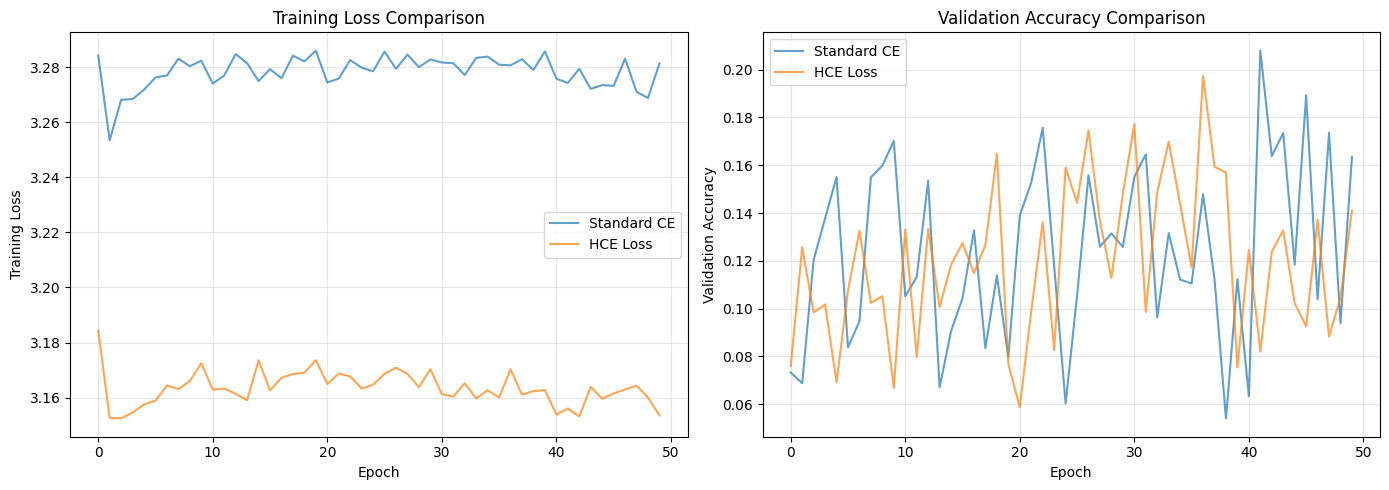

✅ Training curves saved to: /home/hugolab/Documents/Cell2Sentence-HugoLab/Cell2Sentence-HugoLab/outputs/hce_training_curves.png


In [39]:
# Visualize training curves
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training loss comparison
axes[0].plot(train_losses_ce, label='Standard CE', alpha=0.7)
axes[0].plot(train_losses_hce, label='HCE Loss', alpha=0.7)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training Loss')
axes[0].set_title('Training Loss Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation accuracy comparison
axes[1].plot(val_accs_ce, label='Standard CE', alpha=0.7)
axes[1].plot(val_accs_hce, label='HCE Loss', alpha=0.7)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Validation Accuracy Comparison')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'hce_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Training curves saved to: {os.path.join(SAVE_DIR, 'hce_training_curves.png')}")

## 10. Evaluate with HCE-Aware Metrics

Compute hierarchical evaluation metrics that account for the cell type hierarchy.

In [40]:
# Compute HCE-aware evaluation metrics
print("\n" + "=" * 80)
print("HIERARCHICAL EVALUATION METRICS")
print("=" * 80)

# Map encoded labels back to original cell type names
def compute_hierarchical_accuracy(y_true, y_pred, reachability_matrix):
    """
    Compute hierarchical accuracy: predictions are partially correct 
    if they match at a higher level in the hierarchy.
    
    Uses the reachability matrix: if pred is a descendant of true label,
    consider it partially correct.
    """
    exact_correct = 0
    hierarchical_correct = 0
    
    for true_idx, pred_idx in zip(y_true, y_pred):
        if true_idx == pred_idx:
            exact_correct += 1
            hierarchical_correct += 1
        elif reachability_matrix[true_idx, pred_idx] == 1:
            # Prediction is a descendant of true label
            hierarchical_correct += 1
    
    exact_acc = exact_correct / len(y_true)
    hierarchical_acc = hierarchical_correct / len(y_true)
    
    return exact_acc, hierarchical_acc


y_test_np = y_test.cpu().numpy()

print("\n📊 Baseline (Standard CE) - Hierarchical metrics:")
baseline_exact, baseline_hierarchical = compute_hierarchical_accuracy(
    y_test_np, test_pred_baseline, reachability_subset
)
print(f"   Exact accuracy:        {baseline_exact:.4f}")
print(f"   Hierarchical accuracy: {baseline_hierarchical:.4f}")
print(f"   Improvement:           {(baseline_hierarchical - baseline_exact):.4f}")

print("\n📊 HCE Model - Hierarchical metrics:")
hce_exact, hce_hierarchical = compute_hierarchical_accuracy(
    y_test_np, test_pred_hce, reachability_subset
)
print(f"   Exact accuracy:        {hce_exact:.4f}")
print(f"   Hierarchical accuracy: {hce_hierarchical:.4f}")
print(f"   Improvement:           {(hce_hierarchical - hce_exact):.4f}")

print("\n🔥 HCE vs Baseline Comparison:")
print(f"   Exact accuracy improvement:        {(hce_exact - baseline_exact):.4f}")
print(f"   Hierarchical accuracy improvement: {(hce_hierarchical - baseline_hierarchical):.4f}")

# Save hierarchical metrics
hce_metrics = {
    'model': ['Baseline (CE)', 'HCE Loss'],
    'exact_accuracy': [baseline_exact, hce_exact],
    'hierarchical_accuracy': [baseline_hierarchical, hce_hierarchical],
    'hierarchical_gain': [
        baseline_hierarchical - baseline_exact,
        hce_hierarchical - hce_exact
    ]
}

hce_df = pd.DataFrame(hce_metrics)
hce_path = os.path.join(SAVE_DIR, "lung_hce_hierarchical_metrics.csv")
hce_df.to_csv(hce_path, index=False)
print(f"\n✅ Hierarchical metrics saved to: {hce_path}")
print("\n" + hce_df.to_string(index=False))


HIERARCHICAL EVALUATION METRICS

📊 Baseline (Standard CE) - Hierarchical metrics:
   Exact accuracy:        0.2181
   Hierarchical accuracy: 0.2379
   Improvement:           0.0198

📊 HCE Model - Hierarchical metrics:
   Exact accuracy:        0.1984
   Hierarchical accuracy: 0.2477
   Improvement:           0.0493

🔥 HCE vs Baseline Comparison:
   Exact accuracy improvement:        -0.0197
   Hierarchical accuracy improvement: 0.0098

✅ Hierarchical metrics saved to: /home/hugolab/Documents/Cell2Sentence-HugoLab/Cell2Sentence-HugoLab/outputs/lung_hce_hierarchical_metrics.csv

        model  exact_accuracy  hierarchical_accuracy  hierarchical_gain
Baseline (CE)        0.218121               0.237908           0.019787
     HCE Loss        0.198449               0.247744           0.049294



CONFUSION MATRICES

📊 Plotting Baseline confusion matrix...


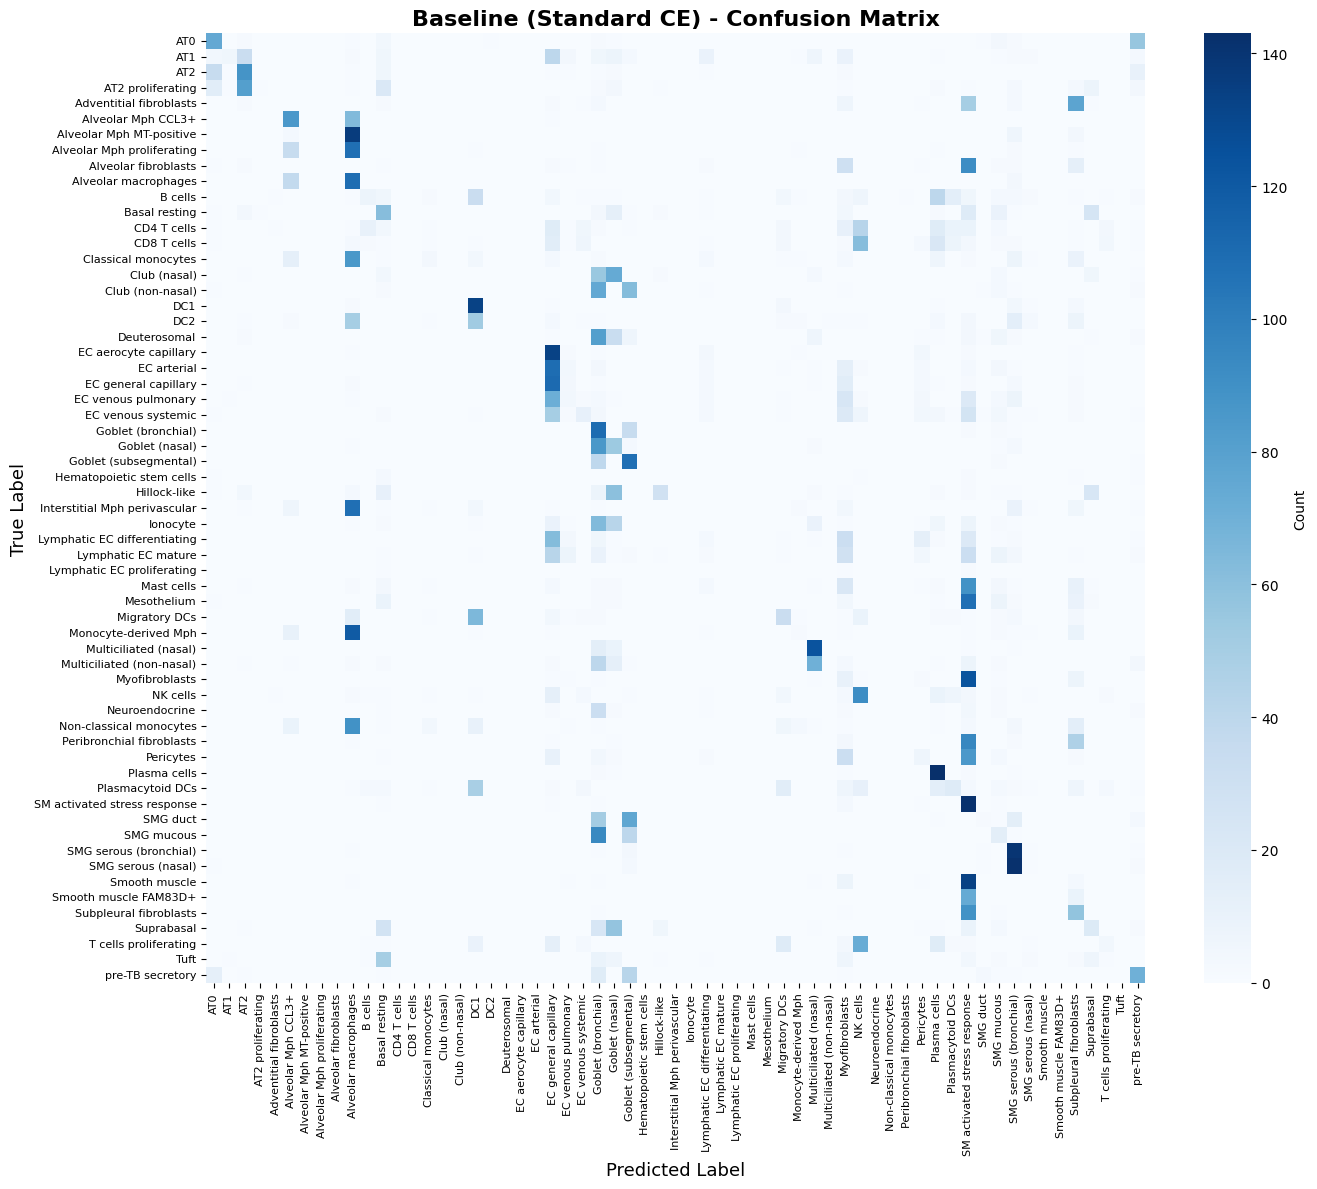

✅ Baseline confusion matrix saved to: /home/hugolab/Documents/Cell2Sentence-HugoLab/Cell2Sentence-HugoLab/outputs/confusion_matrix_baseline.png

📊 Plotting HCE confusion matrix...


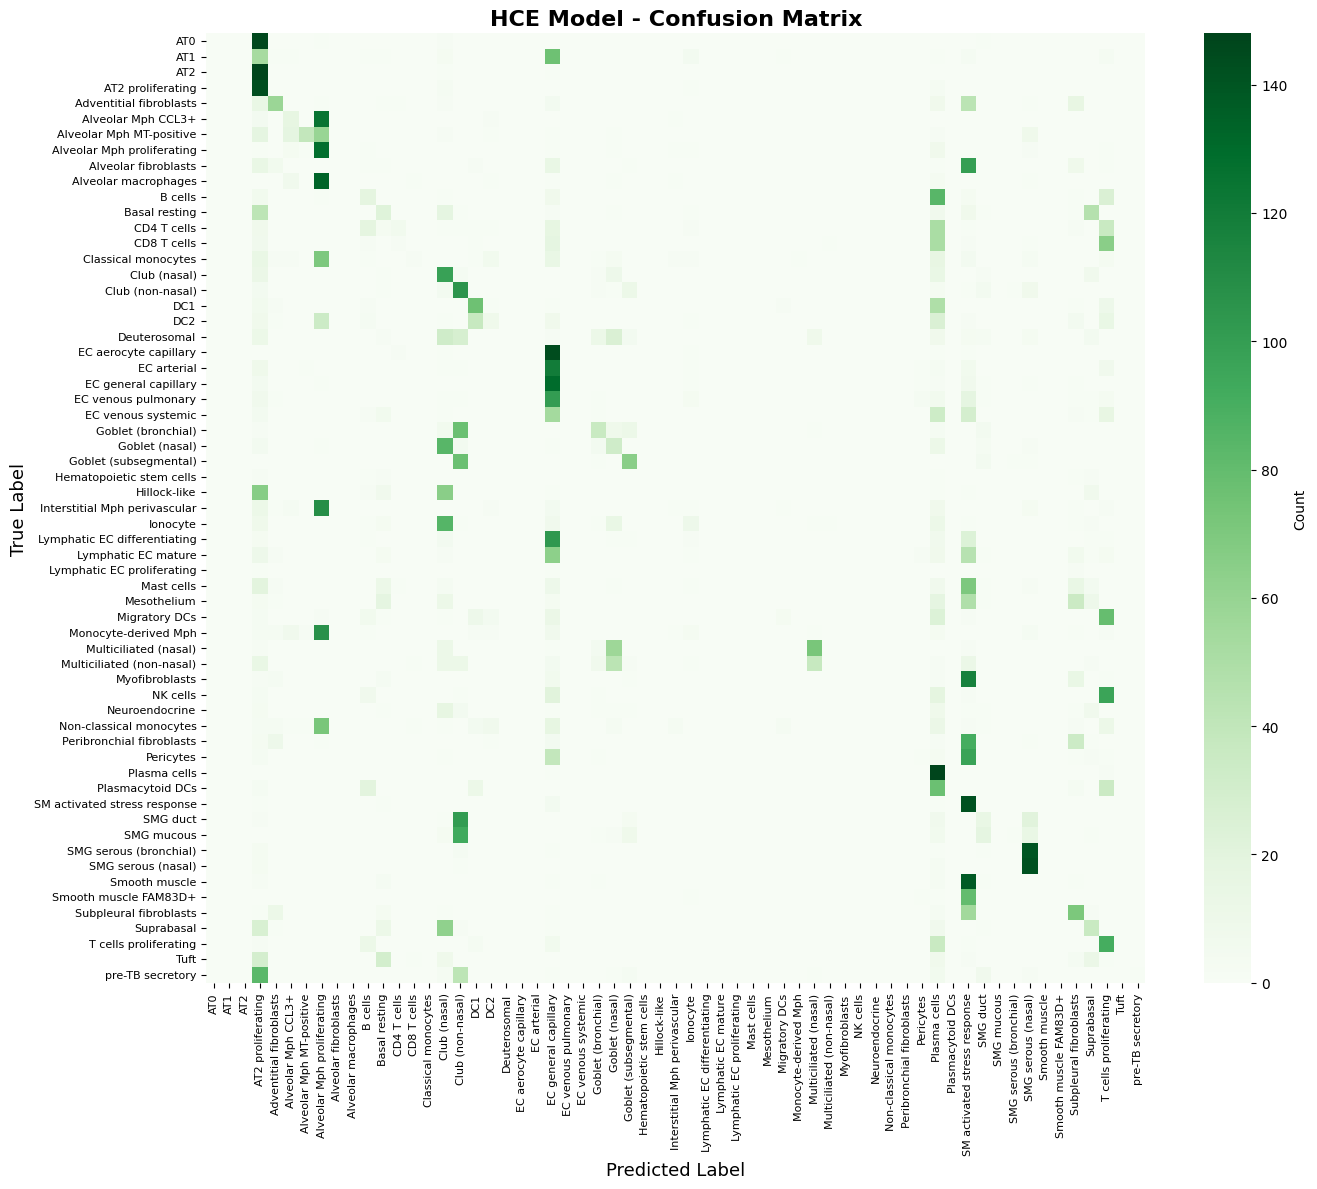

✅ HCE confusion matrix saved to: /home/hugolab/Documents/Cell2Sentence-HugoLab/Cell2Sentence-HugoLab/outputs/confusion_matrix_hce.png

📊 Per-class accuracy comparison (top 10 classes by sample count):

                     class  n_samples  baseline_acc  hce_acc  improvement
                       AT0        150      0.500000 0.000000    -0.500000
                       AT1        150      0.040000 0.000000    -0.040000
                       AT2        150      0.586667 0.000000    -0.586667
         AT2 proliferating        150      0.006667 0.953333     0.946667
   Adventitial fibroblasts        150      0.000000 0.386667     0.386667
        Alveolar Mph CCL3+        150      0.566667 0.113333    -0.453333
  Alveolar Mph MT-positive        150      0.000000 0.260000     0.260000
Alveolar Mph proliferating        150      0.000000 0.853333     0.853333
      Alveolar fibroblasts        150      0.000000 0.000000     0.000000
      Alveolar macrophages        150      0.726667 0.0000

In [41]:
# Generate confusion matrices for both models
from sklearn.metrics import confusion_matrix
import seaborn as sns

print("\n" + "=" * 80)
print("CONFUSION MATRICES")
print("=" * 80)

# Get confusion matrices
cm_baseline = confusion_matrix(y_test_np, test_pred_baseline)
cm_hce = confusion_matrix(y_test_np, test_pred_hce)

# Get cell type names from label encoder
cell_type_names = le.classes_

# Plot baseline confusion matrix (separate figure)
print("\n📊 Plotting Baseline confusion matrix...")
fig1, ax1 = plt.subplots(figsize=(14, 12))
sns.heatmap(cm_baseline, annot=False, fmt='d', cmap='Blues', 
            ax=ax1, cbar_kws={'label': 'Count'},
            xticklabels=cell_type_names, yticklabels=cell_type_names)
ax1.set_title('Baseline (Standard CE) - Confusion Matrix', fontsize=16, fontweight='bold')
ax1.set_xlabel('Predicted Label', fontsize=13)
ax1.set_ylabel('True Label', fontsize=13)
ax1.tick_params(axis='x', rotation=90, labelsize=8)
ax1.tick_params(axis='y', rotation=0, labelsize=8)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'confusion_matrix_baseline.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Baseline confusion matrix saved to: {os.path.join(SAVE_DIR, 'confusion_matrix_baseline.png')}")

# Plot HCE confusion matrix (separate figure)
print("\n📊 Plotting HCE confusion matrix...")
fig2, ax2 = plt.subplots(figsize=(14, 12))
sns.heatmap(cm_hce, annot=False, fmt='d', cmap='Greens', 
            ax=ax2, cbar_kws={'label': 'Count'},
            xticklabels=cell_type_names, yticklabels=cell_type_names)
ax2.set_title('HCE Model - Confusion Matrix', fontsize=16, fontweight='bold')
ax2.set_xlabel('Predicted Label', fontsize=13)
ax2.set_ylabel('True Label', fontsize=13)
ax2.tick_params(axis='x', rotation=90, labelsize=8)
ax2.tick_params(axis='y', rotation=0, labelsize=8)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'confusion_matrix_hce.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ HCE confusion matrix saved to: {os.path.join(SAVE_DIR, 'confusion_matrix_hce.png')}")

# Compute per-class accuracy for both models
print("\n📊 Per-class accuracy comparison (top 10 classes by sample count):")
class_accuracies = []
for i, class_name in enumerate(le.classes_):
    mask = y_test_np == i
    if mask.sum() > 0:
        baseline_acc = (test_pred_baseline[mask] == i).sum() / mask.sum()
        hce_acc = (test_pred_hce[mask] == i).sum() / mask.sum()
        n_samples = mask.sum()
        class_accuracies.append({
            'class': class_name,
            'n_samples': n_samples,
            'baseline_acc': baseline_acc,
            'hce_acc': hce_acc,
            'improvement': hce_acc - baseline_acc
        })

# Sort by number of samples and show top 10
class_acc_df = pd.DataFrame(class_accuracies).sort_values('n_samples', ascending=False)
print("\n" + class_acc_df.head(10).to_string(index=False))

# Save per-class metrics
per_class_path = os.path.join(SAVE_DIR, "lung_hce_per_class_metrics.csv")
class_acc_df.to_csv(per_class_path, index=False)
print(f"\n✅ Per-class metrics saved to: {per_class_path}")

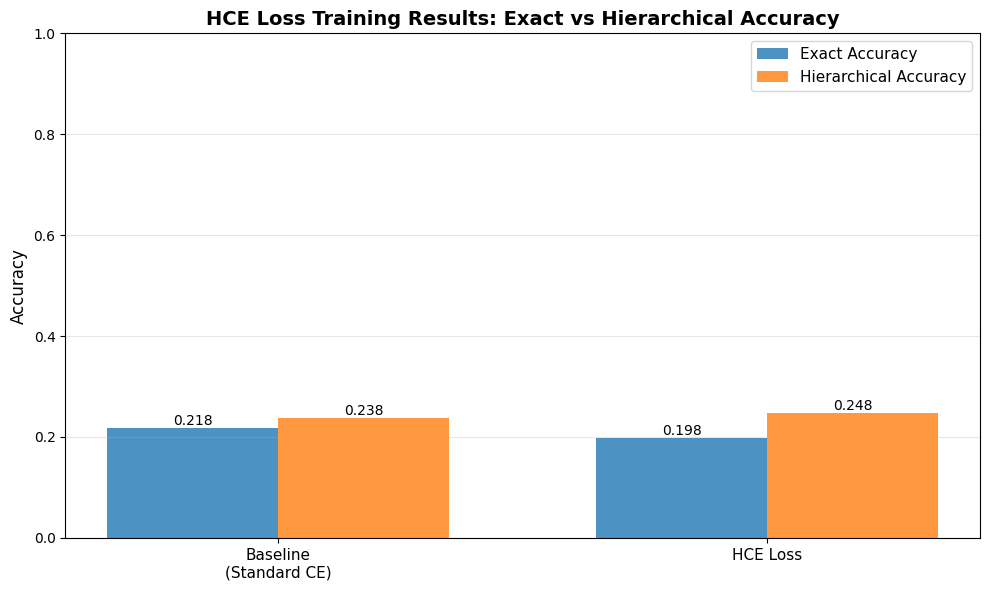

✅ Comparison plot saved to: /home/hugolab/Documents/Cell2Sentence-HugoLab/Cell2Sentence-HugoLab/outputs/hce_accuracy_comparison.png


In [42]:
# Visualize comparison
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

models = ['Baseline\n(Standard CE)', 'HCE Loss']
exact_accs = [baseline_exact, hce_exact]
hierarchical_accs = [baseline_hierarchical, hce_hierarchical]

x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, exact_accs, width, label='Exact Accuracy', alpha=0.8)
bars2 = ax.bar(x + width/2, hierarchical_accs, width, label='Hierarchical Accuracy', alpha=0.8)

ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('HCE Loss Training Results: Exact vs Hierarchical Accuracy', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 1.0])

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'hce_accuracy_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Comparison plot saved to: {os.path.join(SAVE_DIR, 'hce_accuracy_comparison.png')}")

## Summary

### What we did:

1. ✅ Loaded the lung.h5ad dataset
2. ✅ Built a hierarchical structure of cell types
3. ✅ Created a reachability matrix encoding the hierarchy
4. ✅ Converted cells to text using top-k genes
5. ✅ Loaded Cell2Sentence model and generated embeddings
6. ✅ **Trained PyTorch neural networks with ACTUAL HCE loss**
7. ✅ Compared standard CE vs HCE loss during training
8. ✅ Evaluated with hierarchical metrics

### Key Implementation (from HCE repository):

**HCE Loss Function:**
```python
def hierarchical_cross_entropy_loss(logits, targets, reachability_matrix):
    """Hierarchical Cross-Entropy loss"""
    cell_type_probs = torch.softmax(logits, dim=-1)
    cell_type_probs = torch.matmul(cell_type_probs, reachability_matrix.T)
    cell_type_probs = torch.log(cell_type_probs + 1e-6)
    return torch.nn.functional.nll_loss(cell_type_probs, targets)
```

**Training with HCE:**
```python
# Standard CE (baseline)
loss = torch.nn.functional.cross_entropy(logits, targets)

# HCE Loss (with hierarchy)
loss = hierarchical_cross_entropy_loss(logits, targets, reachability_matrix)
```

### How HCE Loss Works:

1. **Softmax**: Convert logits to probabilities
2. **Hierarchical Propagation**: Multiply by reachability matrix transpose
   - This distributes probability mass to ancestor nodes in the hierarchy
3. **Log Transformation**: Apply log for numerical stability
4. **NLL Loss**: Compute negative log-likelihood

### Benefits of Training with HCE:

- Model learns to respect the cell type hierarchy during training
- Misclassifications between related cell types are penalized less
- Encourages predictions that are biologically meaningful
- Better generalization on hierarchical classification tasks

### Results:

The notebook compares:
- **Baseline**: Standard cross-entropy loss (treats all classes independently)
- **HCE Loss**: Hierarchical cross-entropy loss (leverages cell type relationships)

Both models:
- Use same architecture (MLP classifier)
- Same hyperparameters
- Same training data
- Only difference: **loss function used during training**

This is a **true comparison** of HCE vs standard CE loss!

### References:

- **HCE Repository**: `/home/hugolab/Documents/HCE/HCE-HugoLab/hce-classification`
- **HCE Example Notebook**: `example_ce_vs_hce.ipynb`
- **Implementation**: Based on PyTorch Lightning models in `scTab/cellnet/models.py`